Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Am găsit 1342 imagini Normale și 3876 cu Pneumonie în Train.
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Începem antrenarea rețelei...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.4408 - loss: 1.1255 - val_accuracy: 0.7057 - val_loss: 0.6149 - learning_rate: 1.0000e-04
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7799 - loss: 0.7124 - val_accuracy: 0.6606 - val_loss: 0.8240 - learning_rate: 1.0000e-04
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.8096 - loss: 0.6383 - val_accuracy: 0.7469 - val_loss: 0.5724 - learning_rate: 1.0000e-04
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.8553 - loss: 0.5093 - val_accuracy: 0.9185 - val_loss: 0.2284 - learning_rate: 1.0000e-04
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.8577 - loss: 0.5310 - val_accuracy: 0.9147 - val_loss: 0.2201 - learning_rate: 1.0000e-04
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8755 - loss: 0.4427 - val_accuracy: 0.7747 - val_loss: 0.5284 - learning_rate: 1.0000e-04
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - acc

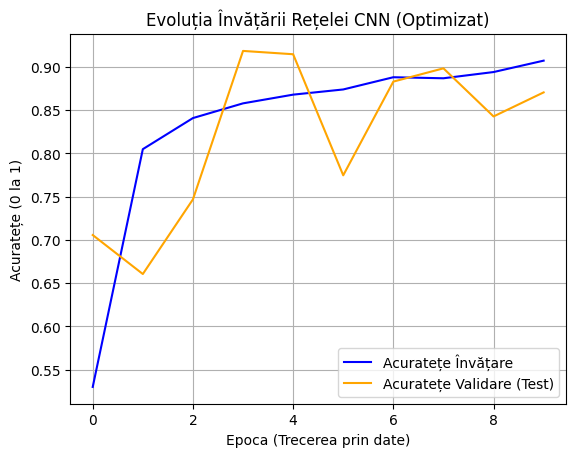

In [2]:
# conectare gdrive
from google.colab import drive
drive.mount('/content/drive')
base_dir = '/content/drive/MyDrive/Proiect_ML/chest_xray'
train_dir = base_dir + '/train'

# import lb deep learn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

# verif nr poze folder antrenament
print(f"Am găsit {len(os.listdir(train_dir + '/NORMAL'))} imagini Normale și {len(os.listdir(train_dir + '/PNEUMONIA'))} cu Pneumonie în Train.")

# pregatim imagini & augmentam
# variam pozele ca sa nu le memoreze
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalizare (aducem pixelii între 0 și 1)
    validation_split=0.2,    # 20% pentru testare
    rotation_range=15,       # rotim usor pozele
    zoom_range=0.2,          # marim pe detalii
    width_shift_range=0.1,   # miscam orizontal
    height_shift_range=0.1   # miscam vertical
)

# invatare 80%
train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',     # 0 = normal, 1 = pneumonia
    subset='training'
)

# testare 20%
val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# echilibrare date (pe normal sa fie de 4 ori mai imp)
weights = {0: 4.0, 1: 1.0}

#  CNN
model = Sequential([
    # filtreaza formele de baza si micsoreaza poza pe esential
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # detectare detalii complexe ( ex. pete/acumulari lichid)
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # ptr detalii mai fine
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(), # lista de date pt procesare
    Dense(128, activation='relu'), # corelam datele
    Dropout(0.5), # ne asiguram ca nu toceste pozele
    Dense(1, activation='sigmoid') # clasificam binar 0/1
])

# optimizam antrenarea cu o viteza mai mica
optimizator = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizator, loss='binary_crossentropy', metrics=['accuracy'])

# oprire daca nu mai e progres, evitam overfitting
callback_oprire = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# reducem viteza la final pt precizie mai mare
callback_viteza = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# train
print("\nÎncepem antrenarea rețelei...")
history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    class_weight=weights,
    callbacks=[callback_oprire, callback_viteza]
)

# graf
plt.plot(history.history['accuracy'], label='Acuratețe Învățare', color='blue')
plt.plot(history.history['val_accuracy'], label='Acuratețe Validare (Test)', color='orange')
plt.title('Evoluția Învățării Rețelei CNN (Optimizat)')
plt.xlabel('Epoca (Trecerea prin date)')
plt.ylabel('Acuratețe (0 la 1)')
plt.legend()
plt.grid(True)

# salvare in gdrive
plt.savefig('/content/drive/MyDrive/Proiect_ML/grafic_rezultate.png')
model.save('/content/drive/MyDrive/Proiect_ML/model_pneumonie.keras')
print("Modelul optimizat și graficul au fost salvate în Drive!")
plt.show()